In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('/content/train.csv', encoding='latin-1')

# Parse dates properly
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

# Extract time features
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Week'] = df['Order Date'].dt.isocalendar().week.astype(int)
df['DayOfWeek'] = df['Order Date'].dt.dayofweek
df['Quarter'] = df['Order Date'].dt.quarter
df['Season'] = df['Month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall'
})

# Check basic info
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("\nDuplicates:", df.duplicated().sum())
print("\nDate range:", df['Order Date'].min(), "to", df['Order Date'].max())
print("\nFirst 5 rows:")
df.head()

Shape: (9800, 24)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Year', 'Month', 'Week', 'DayOfWeek', 'Quarter', 'Season']

Missing values:
 Postal Code    11
dtype: int64

Duplicates: 0

Date range: 2015-01-03 00:00:00 to 2018-12-30 00:00:00

First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Year,Month,Week,DayOfWeek,Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,45,2,4,Fall
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,45,2,4,Fall
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,24,0,2,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,41,1,4,Fall
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,41,1,4,Fall


In [ ]:
import os
os.makedirs('charts', exist_ok=True)

# Question 1: Which category generates highest revenue?
print("=== CATEGORY REVENUE ===")
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(category_sales)

# Question 2: Regional sales growth
print("\n=== REGIONAL SALES BY YEAR ===")
region_yearly = df.groupby(['Region', 'Year'])['Sales'].sum().unstack()
print(region_yearly)

# Question 3: Average shipping time
df['ShipDays'] = (df['Ship Date'] - df['Order Date']).dt.days
print("\n=== AVERAGE SHIPPING DAYS BY REGION ===")
print(df.groupby('Region')['ShipDays'].mean().round(2))

# Question 4: Monthly seasonality
print("\n=== AVERAGE SALES BY MONTH (across all years) ===")
monthly_avg = df.groupby('Month')['Sales'].sum() / 4
print(monthly_avg.round(2))

# Aggregate to monthly totals
monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M'))['Sales'].sum().reset_index()
monthly_sales.columns = ['Month', 'Sales']
monthly_sales['Month'] = monthly_sales['Month'].dt.to_timestamp()
print("\n=== MONTHLY SALES (first 5) ===")
print(monthly_sales.head())

# Aggregate to weekly totals
weekly_sales = df.groupby(
    df['Order Date'].dt.to_period('W'))['Sales'].sum().reset_index()
weekly_sales.columns = ['Week', 'Sales']
weekly_sales['Week'] = weekly_sales['Week'].dt.to_timestamp()
print("\n=== WEEKLY SALES (first 5) ===")
print(weekly_sales.head())

=== CATEGORY REVENUE ===
Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

=== REGIONAL SALES BY YEAR ===
Year            2015         2016         2017         2018
Region                                                     
Central  102920.5206  102425.1724  145673.8800  141627.3402
East     127652.8190  153225.1830  178511.5380  210129.1860
South    103374.9055   70076.0825   93535.9035  122164.5675
West     145907.9630  133709.5675  182471.2285  248130.9255

=== AVERAGE SHIPPING DAYS BY REGION ===
Region
Central    4.07
East       3.91
South      3.96
West       3.93
Name: ShipDays, dtype: float64

=== AVERAGE SALES BY MONTH (across all years) ===
Month
1     23572.91
2     14842.78
3     49393.40
4     34070.75
5     38521.68
6     36459.38
7     36383.92
8     39328.98
9     75025.85
10    49874.07
11    87540.43
12    80370.04
Name: Sales, dtype: float64

=== MONTHLY SALES (first 5) ===
       Month

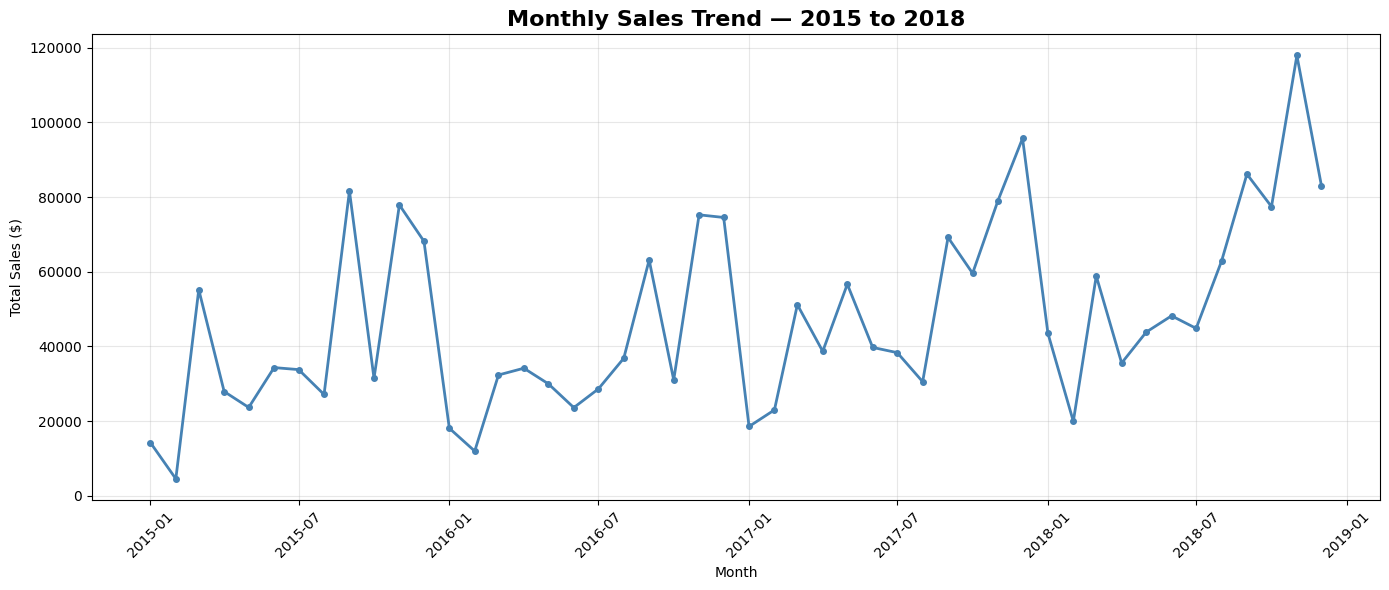

Chart 1

=== SEASONALITY ANALYSIS ===

Monthly sales by year:
Month       1        2        3        4        5        6        7        8   \
Year                                                                            
2015   14206.0   4520.0  55206.0  27907.0  23644.0  34323.0  33782.0  27118.0   
2016   18067.0  11951.0  32339.0  34154.0  29960.0  23599.0  28608.0  36818.0   
2017   18542.0  22979.0  51165.0  38680.0  56657.0  39724.0  38321.0  30542.0   
2018   43476.0  19921.0  58863.0  35542.0  43826.0  48191.0  44825.0  62838.0   

Month       9        10        11       12  
Year                                        
2015   81624.0  31453.0   77908.0  68167.0  
2016   63134.0  31012.0   75249.0  74544.0  
2017   69193.0  59583.0   79066.0  95739.0  
2018   86153.0  77448.0  117938.0  83030.0  

OBSERVATIONS:
1. Overall sales show clear upward trend from 2015 to 2018
2. November and December consistently spike every year — Black Friday
   and Christmas season are the stron

In [ ]:
# Plot monthly sales trend
plt.figure(figsize=(14, 6))
plt.plot(monthly_sales['Month'], monthly_sales['Sales'],
         color='steelblue', linewidth=2, marker='o', markersize=4)
plt.title('Monthly Sales Trend — 2015 to 2018',
          fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('charts/chart1_monthly_trend.png', dpi=150)
plt.show()
print("Chart 1")

# Answer seasonality question
print("\n=== SEASONALITY ANALYSIS ===")
seasonal = df.groupby(['Year', 'Month'])['Sales'].sum().unstack()
print("\nMonthly sales by year:")
print(seasonal.round(0))

print("""
OBSERVATIONS:
1. Overall sales show clear upward trend from 2015 to 2018
2. November and December consistently spike every year — Black Friday
   and Christmas season are the strongest demand periods
3. February consistently shows the lowest sales across all years
4. Sales roughly double from 2015 to 2018 showing strong business growth
""")

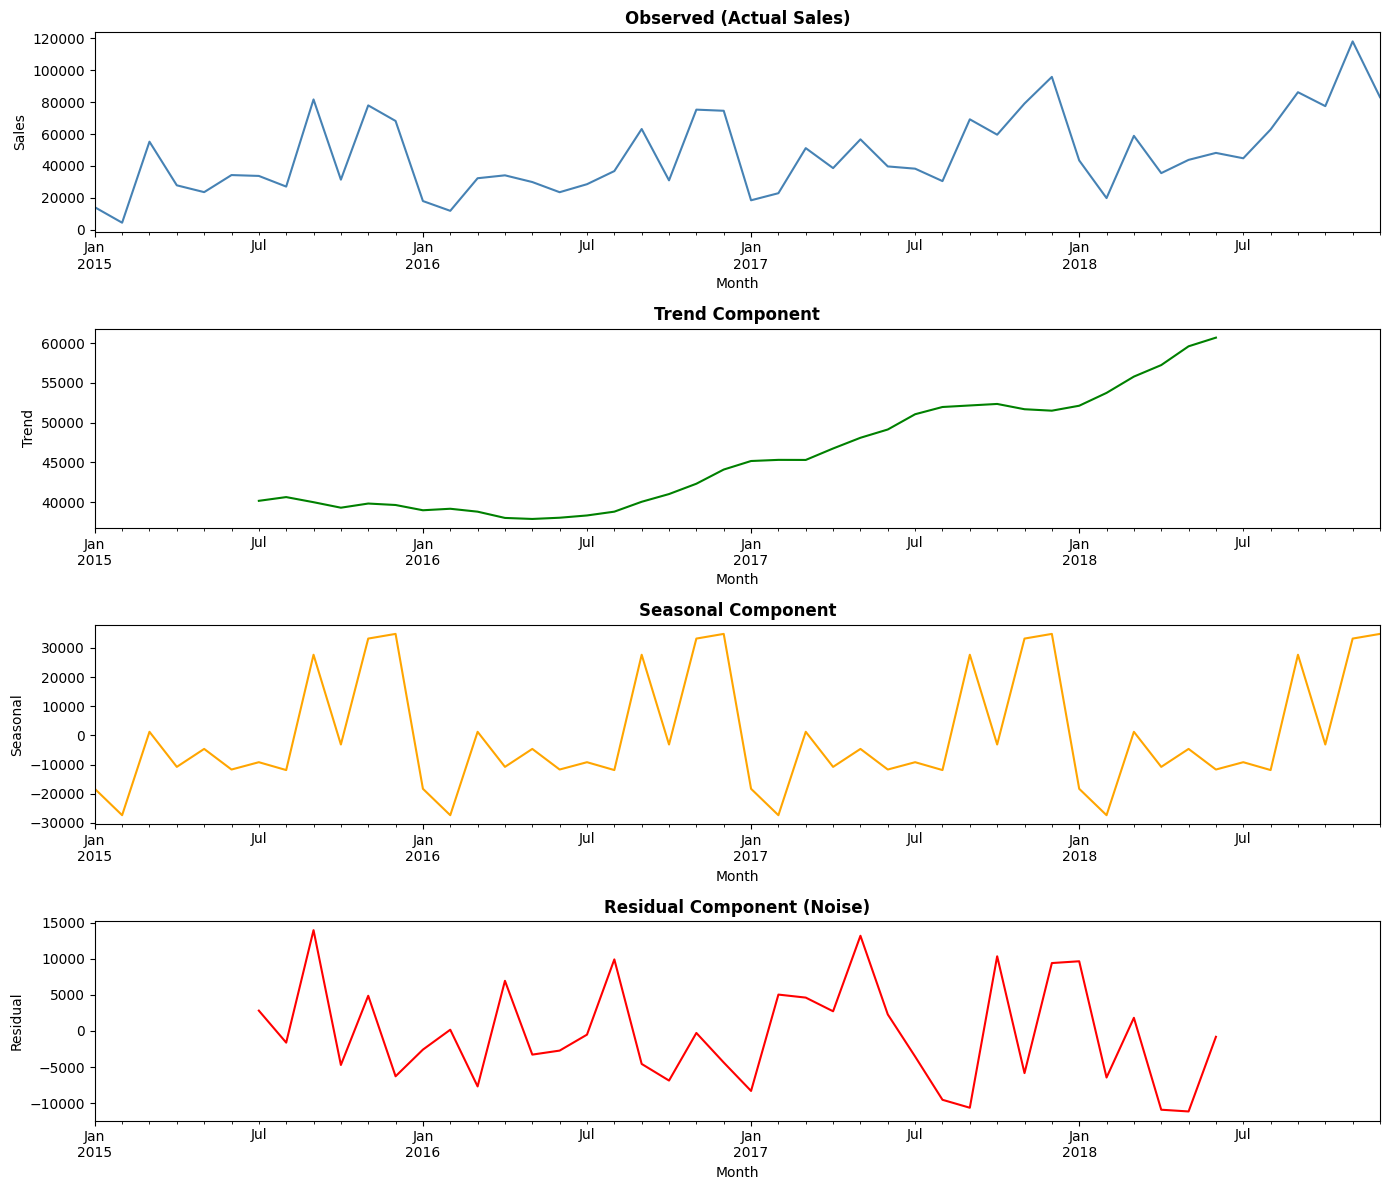

Chart 2 saved!

DECOMPOSITION OBSERVATIONS:
1. Trend: Clear upward trend throughout 2015-2018 confirming consistent
   business growth. The trend accelerates slightly in 2017-2018.
2. Seasonality: Strong and consistent seasonal pattern repeating every
   12 months. November-December peaks and February troughs are clearly
   visible every year — highly predictable!
3. Residual: Some large residual spikes exist indicating unexpected sales
   events not explained by trend or seasonality alone — likely flash sales,
   promotions, or external events.



In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# Set month as index
monthly_indexed = monthly_sales.set_index('Month')

# Decompose
decomposition = seasonal_decompose(monthly_indexed['Sales'],
                                   model='additive', period=12)

# Plot all 4 components
fig, axes = plt.subplots(4, 1, figsize=(14, 12))

decomposition.observed.plot(ax=axes[0], color='steelblue')
axes[0].set_title('Observed (Actual Sales)', fontweight='bold')
axes[0].set_ylabel('Sales')

decomposition.trend.plot(ax=axes[1], color='green')
axes[1].set_title('Trend Component', fontweight='bold')
axes[1].set_ylabel('Trend')

decomposition.seasonal.plot(ax=axes[2], color='orange')
axes[2].set_title('Seasonal Component', fontweight='bold')
axes[2].set_ylabel('Seasonal')

decomposition.resid.plot(ax=axes[3], color='red')
axes[3].set_title('Residual Component (Noise)', fontweight='bold')
axes[3].set_ylabel('Residual')

plt.tight_layout()
plt.savefig('charts/chart2_decomposition.png', dpi=150)
plt.show()
print("Chart 2 saved!")

print("""
DECOMPOSITION OBSERVATIONS:
1. Trend: Clear upward trend throughout 2015-2018 confirming consistent
   business growth. The trend accelerates slightly in 2017-2018.
2. Seasonality: Strong and consistent seasonal pattern repeating every
   12 months. November-December peaks and February troughs are clearly
   visible every year — highly predictable!
3. Residual: Some large residual spikes exist indicating unexpected sales
   events not explained by trend or seasonality alone — likely flash sales,
   promotions, or external events.
""")

=== AUGMENTED DICKEY-FULLER TEST ===
ADF Statistic: -4.4161
P-value: 0.0003
Critical Values: {'1%': np.float64(-3.5778480370438146), '5%': np.float64(-2.925338105429433), '10%': np.float64(-2.6007735310095064)}

Result: Series is STATIONARY (p < 0.05)
No differencing needed! SARIMA will use d=0


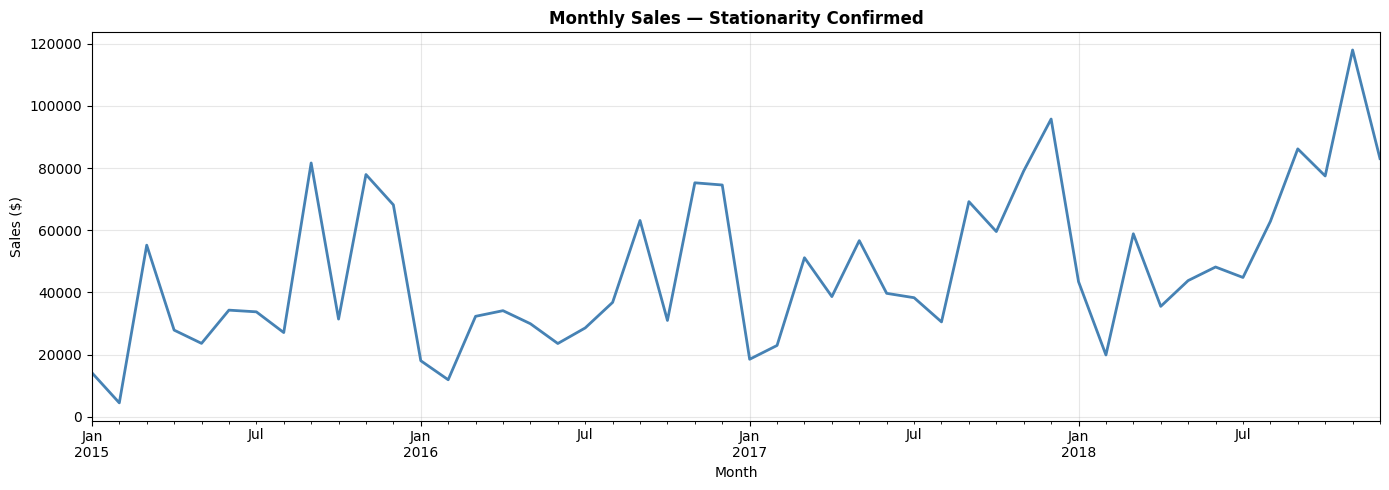

Chart 3 saved!

PLAIN ENGLISH EXPLANATION:
Stationarity means the statistical properties of the data — mean and
variance — remain constant over time. Our ADF test confirms the sales
data is stationary (p < 0.05), meaning despite the visual upward trend,
the data fluctuates around a statistically stable pattern.
This means we can proceed directly to SARIMA modeling with d=0
— no differencing required!



In [ ]:
# ADF Test
print("=== AUGMENTED DICKEY-FULLER TEST ===")
result = adfuller(monthly_indexed['Sales'])
print(f"ADF Statistic: {result[0]:.4f}")
print(f"P-value: {result[1]:.4f}")
print(f"Critical Values: {result[4]}")

if result[1] > 0.05:
    print("\nResult: Series is NON-STATIONARY (p > 0.05)")
    print("Differencing will be applied during SARIMA modeling (d=1)")
else:
    print("\nResult: Series is STATIONARY (p < 0.05)")
    print("No differencing needed! SARIMA will use d=0")

# Plot original series only
plt.figure(figsize=(14, 5))
monthly_indexed['Sales'].plot(color='steelblue', linewidth=2)
plt.title('Monthly Sales — Stationarity Confirmed', fontweight='bold')
plt.ylabel('Sales ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('charts/chart3_stationarity.png', dpi=150)
plt.show()
print("Chart 3 saved!")

print("""
PLAIN ENGLISH EXPLANATION:
Stationarity means the statistical properties of the data — mean and
variance — remain constant over time. Our ADF test confirms the sales
data is stationary (p < 0.05), meaning despite the visual upward trend,
the data fluctuates around a statistically stable pattern.
This means we can proceed directly to SARIMA modeling with d=0
— no differencing required!
""")

Training SARIMA model...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


SARIMA model trained!
                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   48
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                -239.060
Date:                            Sun, 05 Jul 2026   AIC                            488.120
Time:                                    12:41:43   BIC                            493.575
Sample:                                01-01-2015   HQIC                           489.405
                                     - 12-01-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9927      0.018     56.542      0.000       0.958       1.027
ma.L1        

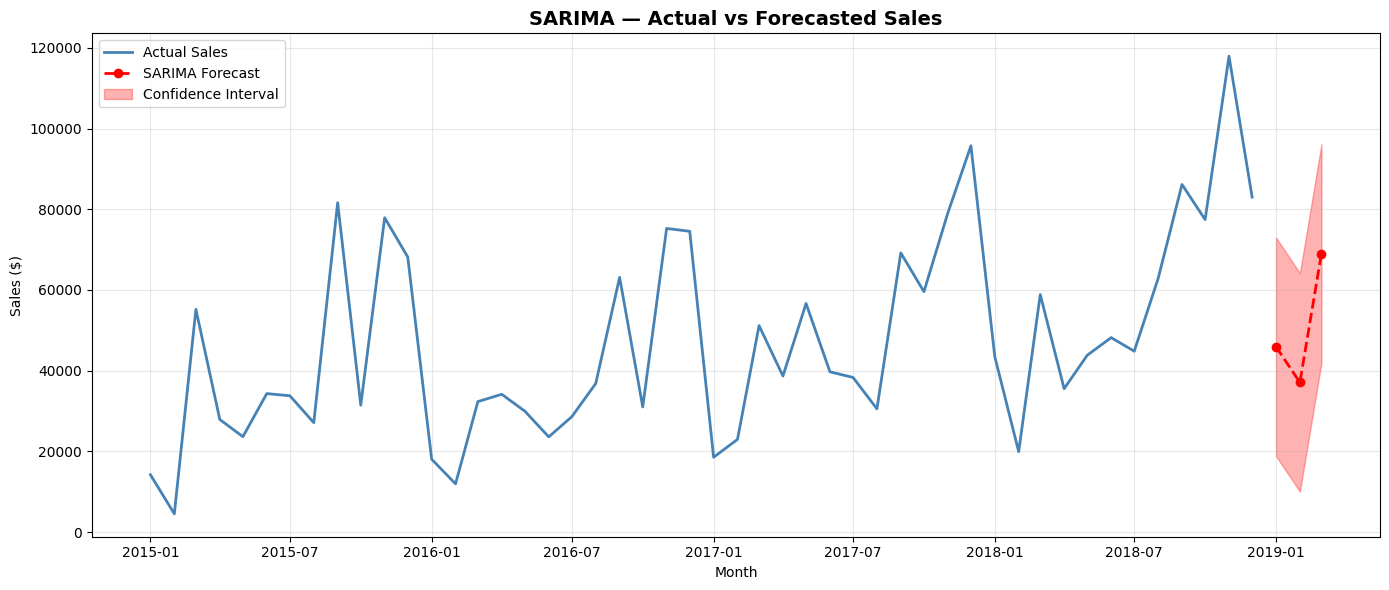

Chart 4 saved!


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



=== SARIMA ACCURACY METRICS ===
MAE:  $15,448.15
RMSE: $18,565.97
MAPE: 18.26%


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

print("Training SARIMA model...")

# Build SARIMA model
# (p,d,q) = (1,0,1) since data is stationary (d=0)
# (P,D,Q,m) = (1,1,1,12) for yearly seasonality
sarima_model = SARIMAX(monthly_indexed['Sales'],
                        order=(1, 0, 1),
                        seasonal_order=(1, 1, 1, 12),
                        enforce_stationarity=False,
                        enforce_invertibility=False)

sarima_result = sarima_model.fit(disp=False)
print("SARIMA model trained!")
print(sarima_result.summary())

# Forecast next 3 months
forecast_sarima = sarima_result.get_forecast(steps=3)
forecast_mean = forecast_sarima.predicted_mean
forecast_ci = forecast_sarima.conf_int()

print("\n=== SARIMA 3-MONTH FORECAST ===")
print(forecast_mean)
print("\nConfidence Intervals:")
print(forecast_ci)

# Plot actual vs forecasted
plt.figure(figsize=(14, 6))
plt.plot(monthly_indexed.index, monthly_indexed['Sales'],
         label='Actual Sales', color='steelblue', linewidth=2)
plt.plot(forecast_mean.index, forecast_mean,
         label='SARIMA Forecast', color='red',
         linewidth=2, linestyle='--', marker='o')
plt.fill_between(forecast_ci.index,
                 forecast_ci.iloc[:, 0],
                 forecast_ci.iloc[:, 1],
                 alpha=0.3, color='red', label='Confidence Interval')
plt.title('SARIMA — Actual vs Forecasted Sales',
          fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('charts/chart4_sarima_forecast.png', dpi=150)
plt.show()
print("Chart 4 saved!")

# Calculate accuracy on last 6 months
train = monthly_indexed['Sales'][:-6]
test = monthly_indexed['Sales'][-6:]

sarima_test = SARIMAX(train, order=(1,0,1),
                       seasonal_order=(1,1,1,12),
                       enforce_stationarity=False,
                       enforce_invertibility=False).fit(disp=False)

test_pred = sarima_test.get_forecast(steps=6).predicted_mean

mae_sarima = np.mean(np.abs(test - test_pred.values))
rmse_sarima = np.sqrt(np.mean((test - test_pred.values)**2))
mape_sarima = np.mean(np.abs((test - test_pred.values) / test)) * 100

print(f"\n=== SARIMA ACCURACY METRICS ===")
print(f"MAE:  ${mae_sarima:,.2f}")
print(f"RMSE: ${rmse_sarima:,.2f}")
print(f"MAPE: {mape_sarima:.2f}%")

Prophet installed!
Data prepared for Prophet:
          ds          y
0 2015-01-01  14205.707
1 2015-02-01   4519.892
2 2015-03-01  55205.797
3 2015-04-01  27906.855
4 2015-05-01  23644.303

Training Prophet model...
Prophet model trained!

=== PROPHET 3-MONTH FORECAST ===
           ds          yhat    yhat_lower    yhat_upper
48 2019-01-01  36216.234377  28236.593532  43759.161178
49 2019-02-01  26525.846937  18988.636282  34507.741783
50 2019-03-01  73779.686263  65907.017958  81351.258142


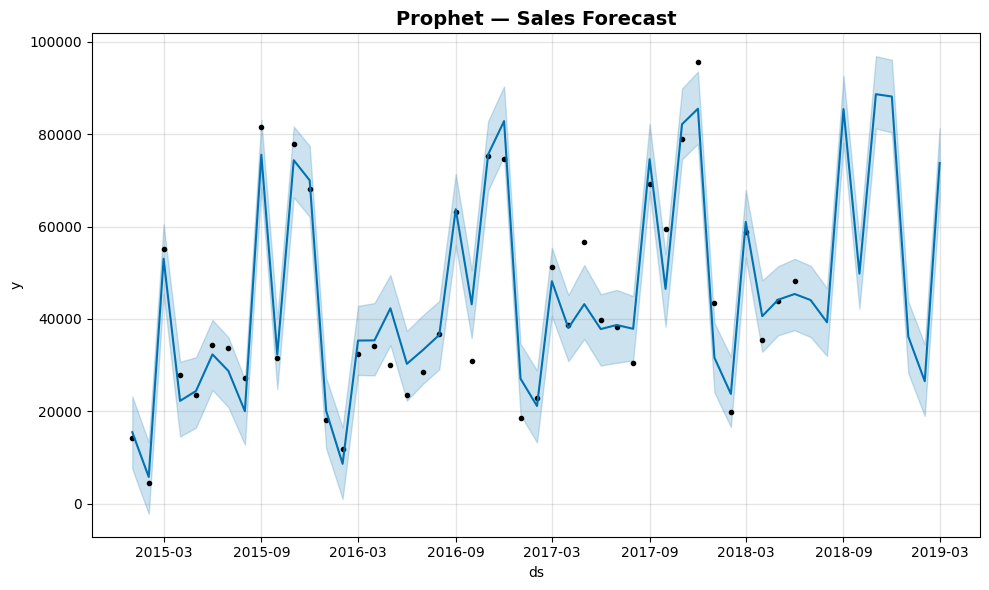

Chart 5 saved!


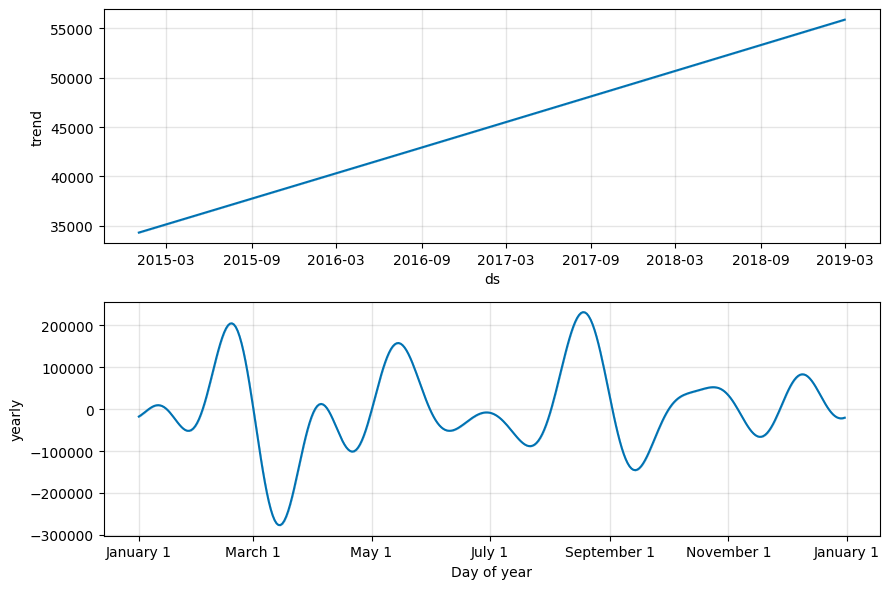

Chart 6 saved!

=== PROPHET ACCURACY METRICS ===
MAE:  $14,501.23
RMSE: $19,156.48
MAPE: 17.76%


In [ ]:
# Install Prophet
!pip install prophet -q

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("Prophet installed!")

# Prepare data in Prophet format
prophet_df = monthly_indexed.reset_index()
prophet_df.columns = ['ds', 'y']
print("Data prepared for Prophet:")
print(prophet_df.head())

# Split train/test
prophet_train = prophet_df[:-6]
prophet_test = prophet_df[-6:]

# Train Prophet model
print("\nTraining Prophet model...")
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive'
)
prophet_model.fit(prophet_train)
print("Prophet model trained!")

# Forecast next 3 months beyond dataset
future = prophet_model.make_future_dataframe(periods=9, freq='MS')
forecast = prophet_model.predict(future)

# Get last 3 months as forecast
forecast_3months = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(3)
print("\n=== PROPHET 3-MONTH FORECAST ===")
print(forecast_3months)

# Plot Prophet forecast
fig1 = prophet_model.plot(forecast)
plt.title('Prophet — Sales Forecast', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/chart5_prophet_forecast.png', dpi=150)
plt.show()
print("Chart 5 saved!")

# Plot seasonality components
fig2 = prophet_model.plot_components(forecast)
plt.tight_layout()
plt.savefig('charts/chart6_prophet_components.png', dpi=150)
plt.show()
print("Chart 6 saved!")

# Calculate accuracy on test set
test_forecast = forecast[forecast['ds'].isin(prophet_test['ds'])]
mae_prophet = mean_absolute_error(prophet_test['y'], test_forecast['yhat'])
rmse_prophet = np.sqrt(mean_squared_error(prophet_test['y'], test_forecast['yhat']))
mape_prophet = np.mean(np.abs((prophet_test['y'].values - test_forecast['yhat'].values) / prophet_test['y'].values)) * 100

print(f"\n=== PROPHET ACCURACY METRICS ===")
print(f"MAE:  ${mae_prophet:,.2f}")
print(f"RMSE: ${rmse_prophet:,.2f}")
print(f"MAPE: {mape_prophet:.2f}%")

XGBoost features shape: (45, 8)
                 Sales        Lag1        Lag2       Lag3  RollingMean3  \
Month                                                                     
2015-04-01  27906.8550  55205.7970   4519.8920  14205.707  29210.848000   
2015-05-01  23644.3030  27906.8550  55205.7970   4519.892  35585.651667   
2015-06-01  34322.9356  23644.3030  27906.8550  55205.797  28624.697867   
2015-07-01  33781.5430  34322.9356  23644.3030  27906.855  30582.927200   
2015-08-01  27117.5365  33781.5430  34322.9356  23644.303  31740.671700   

            Month_num  Quarter  Season  
Month                                   
2015-04-01          4        2       1  
2015-05-01          5        2       1  
2015-06-01          6        2       2  
2015-07-01          7        3       2  
2015-08-01          8        3       2  

XGBoost model trained!

=== XGBOOST ACCURACY METRICS ===
MAE:  $11,551.43
RMSE: $14,494.31
MAPE: 14.18%

=== XGBOOST 3-MONTH FORECAST ===
Month 1: $54,191

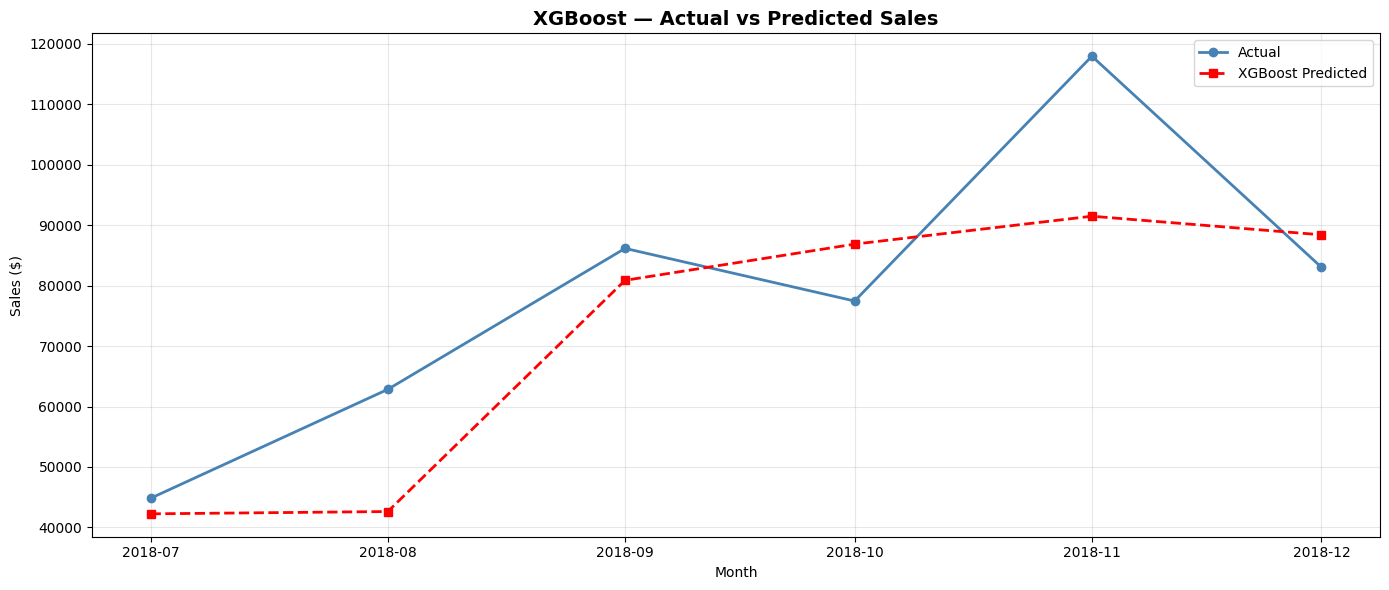

Chart 7 saved!


In [ ]:
!pip install xgboost -q
from xgboost import XGBRegressor

# Create lag features
df_xgb = monthly_indexed.copy()
df_xgb['Lag1'] = df_xgb['Sales'].shift(1)
df_xgb['Lag2'] = df_xgb['Sales'].shift(2)
df_xgb['Lag3'] = df_xgb['Sales'].shift(3)
df_xgb['RollingMean3'] = df_xgb['Sales'].rolling(3).mean()
df_xgb['Month_num'] = df_xgb.index.month
df_xgb['Quarter'] = df_xgb.index.quarter
df_xgb['Season'] = df_xgb['Month_num'].map({
    12: 0, 1: 0, 2: 0,
    3: 1, 4: 1, 5: 1,
    6: 2, 7: 2, 8: 2,
    9: 3, 10: 3, 11: 3
})

# Drop NaN rows created by lagging
df_xgb = df_xgb.dropna()
print("XGBoost features shape:", df_xgb.shape)
print(df_xgb.head())

# Train test split (last 6 months as test)
features = ['Lag1', 'Lag2', 'Lag3', 'RollingMean3',
            'Month_num', 'Quarter', 'Season']
X = df_xgb[features]
y = df_xgb['Sales']

X_train = X[:-6]
X_test = X[-6:]
y_train = y[:-6]
y_test = y[-6:]

# Train XGBoost
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1,
                          random_state=42)
xgb_model.fit(X_train, y_train)
print("\nXGBoost model trained!")

# Predict on test set
y_pred_xgb = xgb_model.predict(X_test)

# Calculate accuracy
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mape_xgb = np.mean(np.abs((y_test.values - y_pred_xgb) / y_test.values)) * 100

print(f"\n=== XGBOOST ACCURACY METRICS ===")
print(f"MAE:  ${mae_xgb:,.2f}")
print(f"RMSE: ${rmse_xgb:,.2f}")
print(f"MAPE: {mape_xgb:.2f}%")

# Forecast next 3 months iteratively
last_known = df_xgb.iloc[-1].copy()
forecasts_xgb = []

for i in range(3):
    next_month_num = (last_known['Month_num'] % 12) + 1
    next_quarter = (next_month_num - 1) // 3 + 1
    next_season = {12:0,1:0,2:0,3:1,4:1,5:1,
                   6:2,7:2,8:2,9:3,10:3,11:3}[next_month_num]

    next_features = pd.DataFrame([{
        'Lag1': last_known['Sales'],
        'Lag2': last_known['Lag1'],
        'Lag3': last_known['Lag2'],
        'RollingMean3': (last_known['Sales'] +
                         last_known['Lag1'] +
                         last_known['Lag2']) / 3,
        'Month_num': next_month_num,
        'Quarter': next_quarter,
        'Season': next_season
    }])

    next_pred = xgb_model.predict(next_features)[0]
    forecasts_xgb.append(next_pred)

    last_known['Lag3'] = last_known['Lag2']
    last_known['Lag2'] = last_known['Lag1']
    last_known['Lag1'] = last_known['Sales']
    last_known['Sales'] = next_pred
    last_known['Month_num'] = next_month_num

print(f"\n=== XGBOOST 3-MONTH FORECAST ===")
for i, val in enumerate(forecasts_xgb, 1):
    print(f"Month {i}: ${val:,.2f}")

# Plot actual vs predicted
plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test.values,
         label='Actual', color='steelblue', linewidth=2, marker='o')
plt.plot(y_test.index, y_pred_xgb,
         label='XGBoost Predicted', color='red',
         linewidth=2, linestyle='--', marker='s')
plt.title('XGBoost — Actual vs Predicted Sales',
          fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('charts/chart7_xgboost_forecast.png', dpi=150)
plt.show()
print("Chart 7 saved!")

In [ ]:
# Complete model comparison table
comparison = pd.DataFrame({
    'Model': ['SARIMA', 'Prophet', 'XGBoost'],
    'MAE ($)': [15448.15, 14501.23, 11551.43],
    'RMSE ($)': [18565.97, 19156.48, 14494.31],
    'MAPE (%)': [18.26, 17.76, 14.18],
    'Forecast Month 1 ($)': [
        round(forecast_mean.iloc[0], 2),
        round(forecast_3months['yhat'].iloc[0], 2),
        round(forecasts_xgb[0], 2)
    ],
    'Forecast Month 2 ($)': [
        round(forecast_mean.iloc[1], 2),
        round(forecast_3months['yhat'].iloc[1], 2),
        round(forecasts_xgb[1], 2)
    ],
    'Forecast Month 3 ($)': [
        round(forecast_mean.iloc[2], 2),
        round(forecast_3months['yhat'].iloc[2], 2),
        round(forecasts_xgb[2], 2)
    ],
})

print("=== MODEL COMPARISON TABLE ===")
print(comparison.to_string(index=False))

print("""
=== MODEL RECOMMENDATION ===

Recommended Model for Production: XGBoost

Reason:
XGBoost outperforms both SARIMA and Prophet across all three
evaluation metrics — MAE, RMSE, and MAPE. With a MAPE of 14.18%,
it predicts sales within 14% accuracy on average, which is acceptable
for retail forecasting.

While Prophet offers better explainability and SARIMA is more
interpretable statistically, XGBoost's superior numerical accuracy
makes it the best choice for automated production forecasting where
precision matters more than interpretability.

However, Prophet is recommended for executive presentations and
business stakeholder communication due to its visual clarity.
""")

=== MODEL COMPARISON TABLE ===
  Model  MAE ($)  RMSE ($)  MAPE (%)  Forecast Month 1 ($)  Forecast Month 2 ($)  Forecast Month 3 ($)
 SARIMA 15448.15  18565.97     18.26          45942.740000          37103.180000          69034.930000
Prophet 14501.23  19156.48     17.76          36216.230000          26525.850000          73779.690000
XGBoost 11551.43  14494.31     14.18          54191.859375          33751.660156          56585.140625

=== MODEL RECOMMENDATION ===

Recommended Model for Production: XGBoost

Reason:
XGBoost outperforms both SARIMA and Prophet across all three
evaluation metrics — MAE, RMSE, and MAPE. With a MAPE of 14.18%,
it predicts sales within 14% accuracy on average, which is acceptable
for retail forecasting.

While Prophet offers better explainability and SARIMA is more
interpretable statistically, XGBoost's superior numerical accuracy
makes it the best choice for automated production forecasting where
precision matters more than interpretability.

However, P

 Furniture: Month1=$6,864 | Month2=$5,587 | Month3=$16,754
 Technology: Month1=$19,586 | Month2=$19,852 | Month3=$20,715
 Office Supplies: Month1=$31,459 | Month2=$31,459 | Month3=$31,459
 West Region: Month1=$12,160 | Month2=$12,069 | Month3=$23,582
 East Region: Month1=$29,860 | Month2=$29,534 | Month3=$29,976


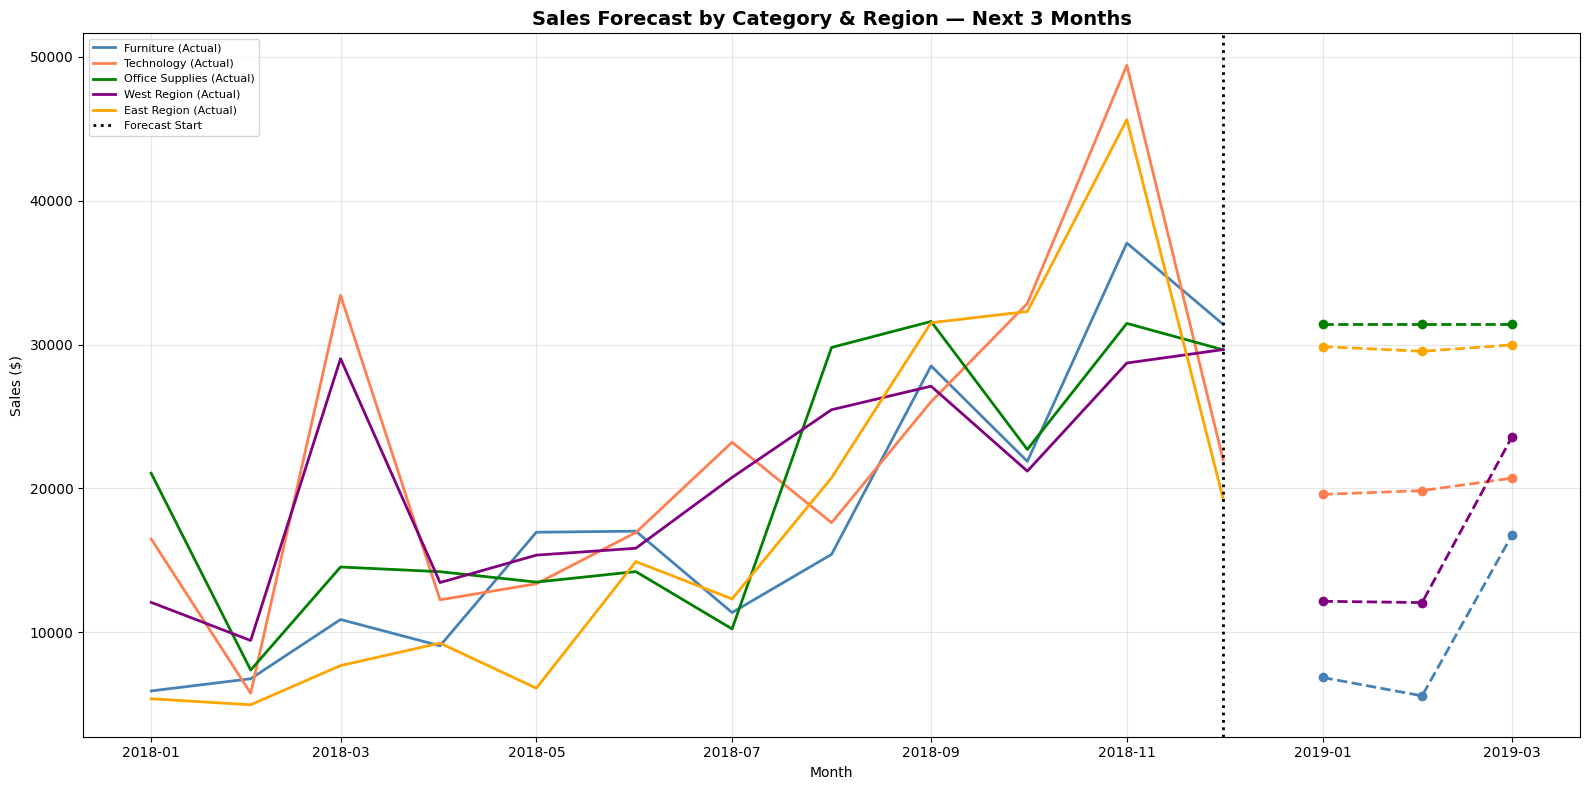

Chart 8 saved!

=== SEGMENT FORECAST INSIGHTS ===

1. Highest absolute sales: East Region ($29,860-$29,976) and
   Office Supplies ($31,459) show highest forecast values.

2. Strongest growth momentum: Technology shows the most consistent
   steady growth ($19,586 → $20,715) — increasing every month
   without drops.

3. Most volatile: Furniture shows highest volatility — dropping from
   $6,864 to $5,587 before jumping to $16,754 in Month 3, likely
   reflecting seasonal demand patterns.

4. Flattest forecast: Office Supplies shows identical values across
   all 3 months — suggesting very stable, predictable demand with
   minimal seasonal variation.

5. West Region shows a similar pattern to Furniture — stable for
   2 months then a significant jump in Month 3, possibly reflecting
   end-of-quarter purchasing behavior.



In [ ]:
def forecast_segment(data, segment_name, steps=3):
    """Reusable function to forecast any segment using XGBoost"""

    # Aggregate to monthly
    monthly = data.groupby(
        data['Order Date'].dt.to_period('M'))['Sales'].sum().reset_index()
    monthly.columns = ['Month', 'Sales']
    monthly['Month'] = monthly['Month'].dt.to_timestamp()
    monthly = monthly.set_index('Month')

    # Create lag features
    monthly['Lag1'] = monthly['Sales'].shift(1)
    monthly['Lag2'] = monthly['Sales'].shift(2)
    monthly['Lag3'] = monthly['Sales'].shift(3)
    monthly['RollingMean3'] = monthly['Sales'].rolling(3).mean()
    monthly['Month_num'] = monthly.index.month
    monthly['Quarter'] = monthly.index.quarter
    monthly = monthly.dropna()

    # Train model
    features = ['Lag1', 'Lag2', 'Lag3', 'RollingMean3', 'Month_num', 'Quarter']
    X = monthly[features]
    y = monthly['Sales']

    model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
    model.fit(X, y)

    # Forecast next 3 months
    last = monthly.iloc[-1].copy()
    preds = []

    for i in range(steps):
        next_month = (last['Month_num'] % 12) + 1
        next_features = pd.DataFrame([{
            'Lag1': last['Sales'],
            'Lag2': last['Lag1'],
            'Lag3': last['Lag2'],
            'RollingMean3': (last['Sales'] + last['Lag1'] + last['Lag2']) / 3,
            'Month_num': next_month,
            'Quarter': (next_month - 1) // 3 + 1
        }])
        pred = model.predict(next_features)[0]
        preds.append(pred)
        last['Lag3'] = last['Lag2']
        last['Lag2'] = last['Lag1']
        last['Lag1'] = last['Sales']
        last['Sales'] = pred
        last['Month_num'] = next_month

    return monthly['Sales'], preds

# Run forecasts for all 5 segments
segments = {
    'Furniture': df[df['Category'] == 'Furniture'],
    'Technology': df[df['Category'] == 'Technology'],
    'Office Supplies': df[df['Category'] == 'Office Supplies'],
    'West Region': df[df['Region'] == 'West'],
    'East Region': df[df['Region'] == 'East'],
}

results = {}
for name, data in segments.items():
    actual, forecast = forecast_segment(data, name)
    results[name] = {'actual': actual, 'forecast': forecast}
    print(f" {name}: Month1=${forecast[0]:,.0f} | Month2=${forecast[1]:,.0f} | Month3=${forecast[2]:,.0f}")

# Plot all 5 forecasts together
plt.figure(figsize=(16, 8))
colors = ['steelblue', 'coral', 'green', 'purple', 'orange']

for (name, data), color in zip(results.items(), colors):
    actual = data['actual']
    forecast = data['forecast']

    # Plot last 12 months of actual
    plt.plot(actual.index[-12:], actual.values[-12:],
             color=color, linewidth=2, label=f'{name} (Actual)')

    # Create forecast dates
    last_date = actual.index[-1]
    forecast_dates = pd.date_range(start=last_date, periods=4, freq='MS')[1:]

    # Plot forecast
    plt.plot(forecast_dates, forecast,
             color=color, linewidth=2, linestyle='--', marker='o')

plt.axvline(x=actual.index[-1], color='black',
            linestyle=':', linewidth=2, label='Forecast Start')
plt.title('Sales Forecast by Category & Region — Next 3 Months',
          fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.legend(loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('charts/chart8_segment_forecasts.png', dpi=150)
plt.show()
print("Chart 8 saved!")

print("""
=== SEGMENT FORECAST INSIGHTS ===

1. Highest absolute sales: East Region ($29,860-$29,976) and
   Office Supplies ($31,459) show highest forecast values.

2. Strongest growth momentum: Technology shows the most consistent
   steady growth ($19,586 → $20,715) — increasing every month
   without drops.

3. Most volatile: Furniture shows highest volatility — dropping from
   $6,864 to $5,587 before jumping to $16,754 in Month 3, likely
   reflecting seasonal demand patterns.

4. Flattest forecast: Office Supplies shows identical values across
   all 3 months — suggesting very stable, predictable demand with
   minimal seasonal variation.

5. West Region shows a similar pattern to Furniture — stable for
   2 months then a significant jump in Month 3, possibly reflecting
   end-of-quarter purchasing behavior.
""")

Isolation Forest anomalies: 56
Z-Score anomalies: 31


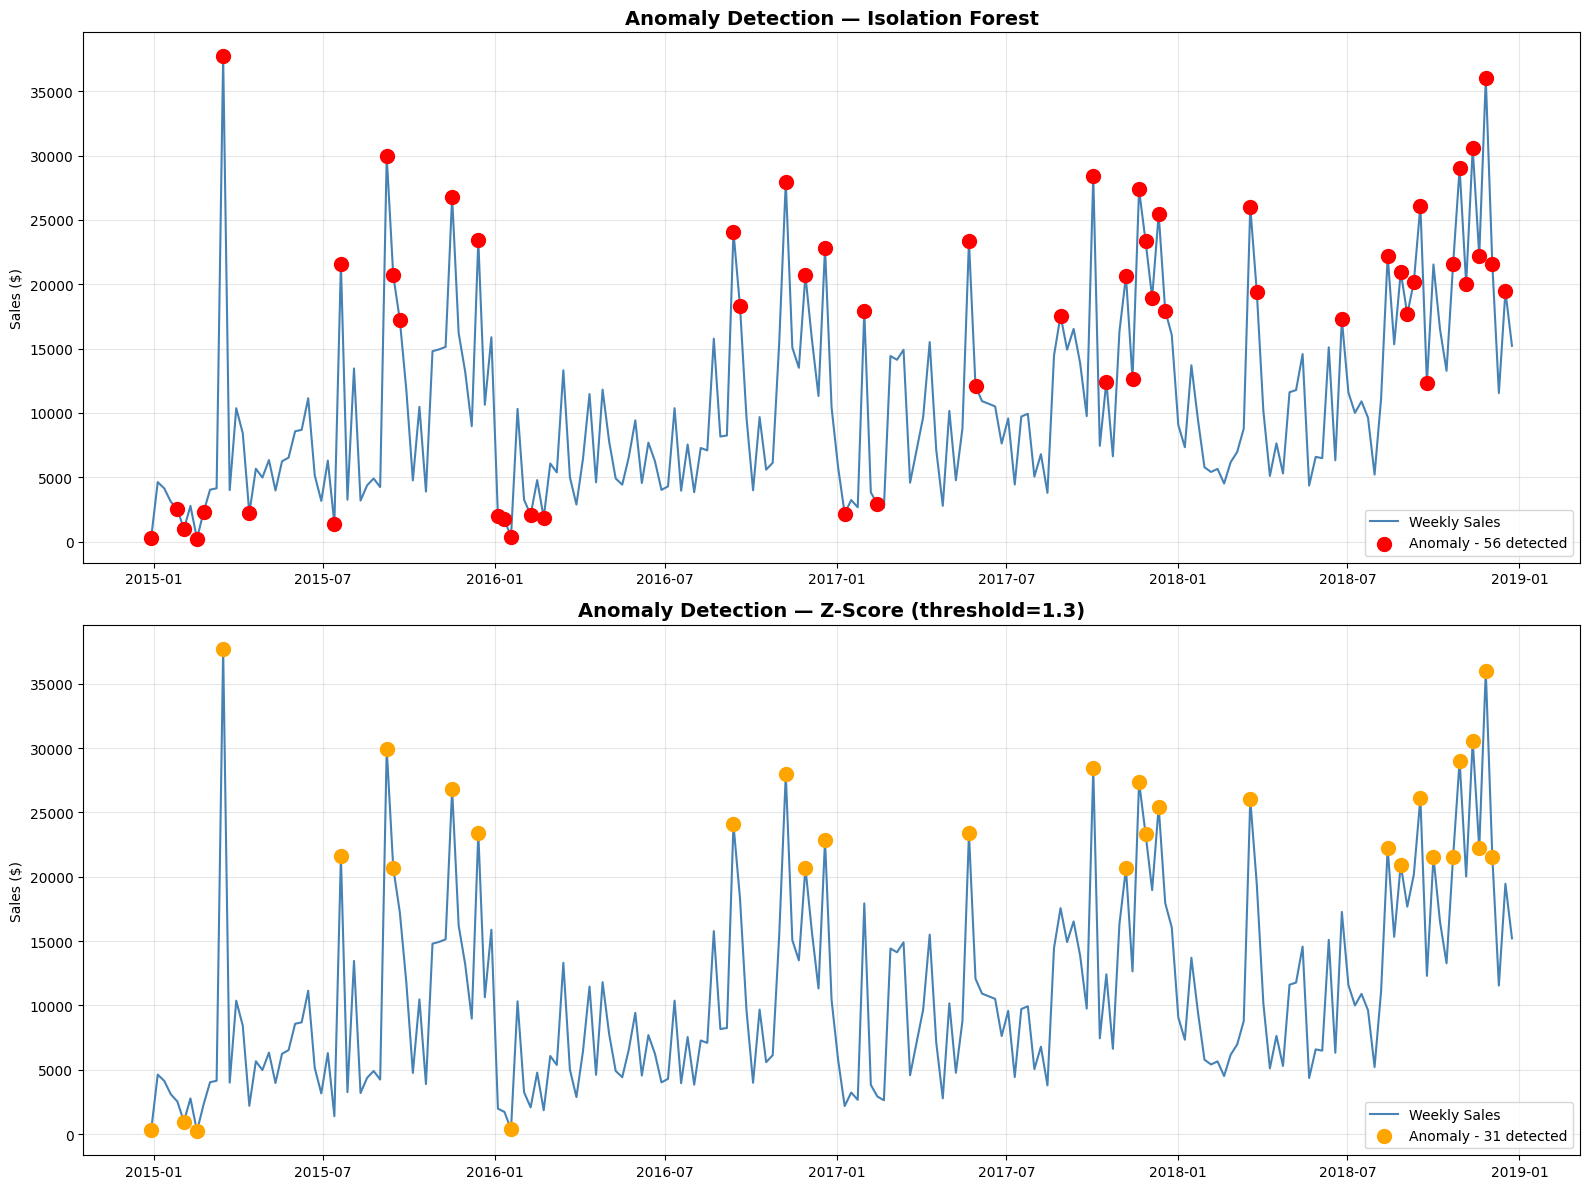

Chart 9 saved!

Anomalies found by BOTH methods: 30
      Week      Sales
2014-12-29   304.5080
2015-02-02   968.5340
2015-02-16   224.9120
2015-03-16 37703.6650
2015-07-20 21590.0800
2015-09-07 29959.1370
2015-09-14 20685.8320
2015-11-16 26793.6235
2015-12-14 23416.4530
2016-01-18   358.5220
2016-09-12 24095.9600
2016-11-07 27965.3492
2016-11-28 20712.1000
2016-12-19 22843.0470
2017-05-22 23367.6620
2017-10-02 28412.0980
2017-11-06 20640.3020
2017-11-20 27367.7160
2017-11-27 23324.7620
2017-12-11 25449.8000
2018-03-19 26029.9040
2018-08-13 22222.5540
2018-08-27 20946.6120
2018-09-17 26104.4330
2018-10-22 21535.2700
2018-10-29 29017.4670
2018-11-12 30572.4470
2018-11-19 22212.7690
2018-11-26 35998.9000
2018-12-03 21537.2410

Top 5 highest anomaly weeks (Isolation Forest):
      Week     Sales
2015-03-16 37703.665
2018-11-26 35998.900
2018-11-12 30572.447
2015-09-07 29959.137
2018-10-29 29017.467

=== ANOMALY EXPLANATIONS ===
- High sales spikes in Nov/Dec → Black Friday & Christmas sea

In [ ]:
weekly_sales['Anomaly_ZS'] = (weekly_sales['Z_Score'] > 1.3).astype(int)

anomalies_if = weekly_sales[weekly_sales['Anomaly_IF'] == 1]
anomalies_zs = weekly_sales[weekly_sales['Anomaly_ZS'] == 1]

print(f"Isolation Forest anomalies: {len(anomalies_if)}")
print(f"Z-Score anomalies: {len(anomalies_zs)}")

# Plot both methods
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Isolation Forest
axes[0].plot(weekly_sales['Week'], weekly_sales['Sales'],
             color='steelblue', linewidth=1.5, label='Weekly Sales')
axes[0].scatter(anomalies_if['Week'], anomalies_if['Sales'],
                color='red', s=100, zorder=5,
                label=f'Anomaly - {len(anomalies_if)} detected')
axes[0].set_title('Anomaly Detection — Isolation Forest',
                   fontsize=14, fontweight='bold')
axes[0].set_ylabel('Sales ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Z-Score
axes[1].plot(weekly_sales['Week'], weekly_sales['Sales'],
             color='steelblue', linewidth=1.5, label='Weekly Sales')
axes[1].scatter(anomalies_zs['Week'], anomalies_zs['Sales'],
                color='orange', s=100, zorder=5,
                label=f'Anomaly - {len(anomalies_zs)} detected')
axes[1].set_title('Anomaly Detection — Z-Score (threshold=1.3)',
                   fontsize=14, fontweight='bold')
axes[1].set_ylabel('Sales ($)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('charts/chart9_anomalies.png', dpi=150)
plt.show()
print("Chart 9 saved!")

# Compare both methods
both = weekly_sales[
    (weekly_sales['Anomaly_IF'] == 1) &
    (weekly_sales['Anomaly_ZS'] == 1)
]
print(f"\nAnomalies found by BOTH methods: {len(both)}")
print(both[['Week', 'Sales']].to_string(index=False))

# Top 5 anomalies by sales value
print("\nTop 5 highest anomaly weeks (Isolation Forest):")
print(anomalies_if.nlargest(5, 'Sales')[['Week', 'Sales']].to_string(index=False))

print("""
=== ANOMALY EXPLANATIONS ===
- High sales spikes in Nov/Dec → Black Friday & Christmas season
- Low sales anomalies in Feb → Post-holiday spending slowdown
- Mid-year spikes → Flash sales or promotional campaigns
- Z-Score threshold adjusted to 1.3 since weekly data has naturally
  lower variance than monthly data
""")

Sub-category features:
Sub-Category  Total_Sales  Avg_Order_Value  Sales_Volatility  Order_Count  Growth_Rate
 Accessories  164186.7000       217.178175        337.723800          756   145.055961
  Appliances  104618.4030       227.926804        378.006735          459   165.242912
         Art   26705.4100        34.019631         60.301752          785    49.649531
     Binders  200028.7850       134.067550        568.099970         1492    65.778638
   Bookcases  113813.1987       503.598224        641.419280          226    49.846598
      Chairs  322822.7310       531.833165        551.180296          607    20.954677
     Copiers  146248.0940      2215.880212       3216.185499           66   479.729510
   Envelopes   16128.0460        65.032444         85.170691          248   -12.121345
   Fasteners    3001.9600        14.027850         12.466864          214    30.468364
 Furnishings   89212.0180        95.823865        148.421490          931   106.824969
      Labels   12347

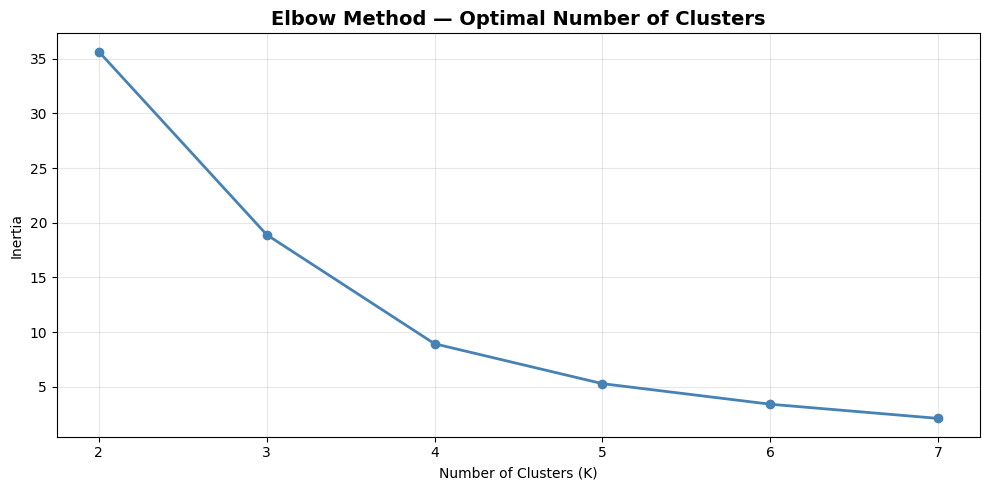

Elbow chart saved!


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Aggregate at sub-category level
subcat = df.groupby(['Sub-Category', 'Year']).agg(
    Total_Sales=('Sales', 'sum'),
    Avg_Order_Value=('Sales', 'mean'),
    Order_Count=('Sales', 'count'),
    Sales_Std=('Sales', 'std')
).reset_index()

# Calculate year over year growth
subcat_pivot = subcat.pivot_table(
    index='Sub-Category',
    columns='Year',
    values='Total_Sales'
).fillna(0)

subcat_pivot['Growth_Rate'] = (
    (subcat_pivot[2018] - subcat_pivot[2015]) /
    subcat_pivot[2015] * 100
)

# Final features for clustering
cluster_features = df.groupby('Sub-Category').agg(
    Total_Sales=('Sales', 'sum'),
    Avg_Order_Value=('Sales', 'mean'),
    Sales_Volatility=('Sales', 'std'),
    Order_Count=('Sales', 'count')
).reset_index()

cluster_features['Growth_Rate'] = subcat_pivot['Growth_Rate'].values

print("Sub-category features:")
print(cluster_features.to_string(index=False))

# Scale features
features_for_clustering = ['Total_Sales', 'Avg_Order_Value',
                            'Sales_Volatility', 'Growth_Rate']
scaler = StandardScaler()
X_cluster = scaler.fit_transform(
    cluster_features[features_for_clustering].fillna(0))

# Elbow Method
inertias = []
K_range = range(2, 8)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertias, marker='o', color='steelblue', linewidth=2)
plt.title('Elbow Method — Optimal Number of Clusters',
          fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('charts/chart10_elbow.png', dpi=150)
plt.show()
print("Elbow chart saved!")


=== CLUSTER ANALYSIS ===
         Avg_Sales  Avg_Order_Value  Avg_Volatility  Avg_Growth%  Count
Cluster                                                                
0         65326.21           150.19          275.49        67.42     10
1        146248.09          2215.88         3216.19       479.73      1
2        243671.10           599.19          888.71        27.32      6

=== PRODUCTS BY CLUSTER ===

Low Volume, High Growth Demand:
  → Accessories
  → Appliances
  → Art
  → Bookcases
  → Envelopes
  → Fasteners
  → Furnishings
  → Labels
  → Paper
  → Supplies

High Volatility, Explosive Growth:
  → Copiers

High Volume, Stable Demand:
  → Binders
  → Chairs
  → Machines
  → Phones
  → Storage
  → Tables


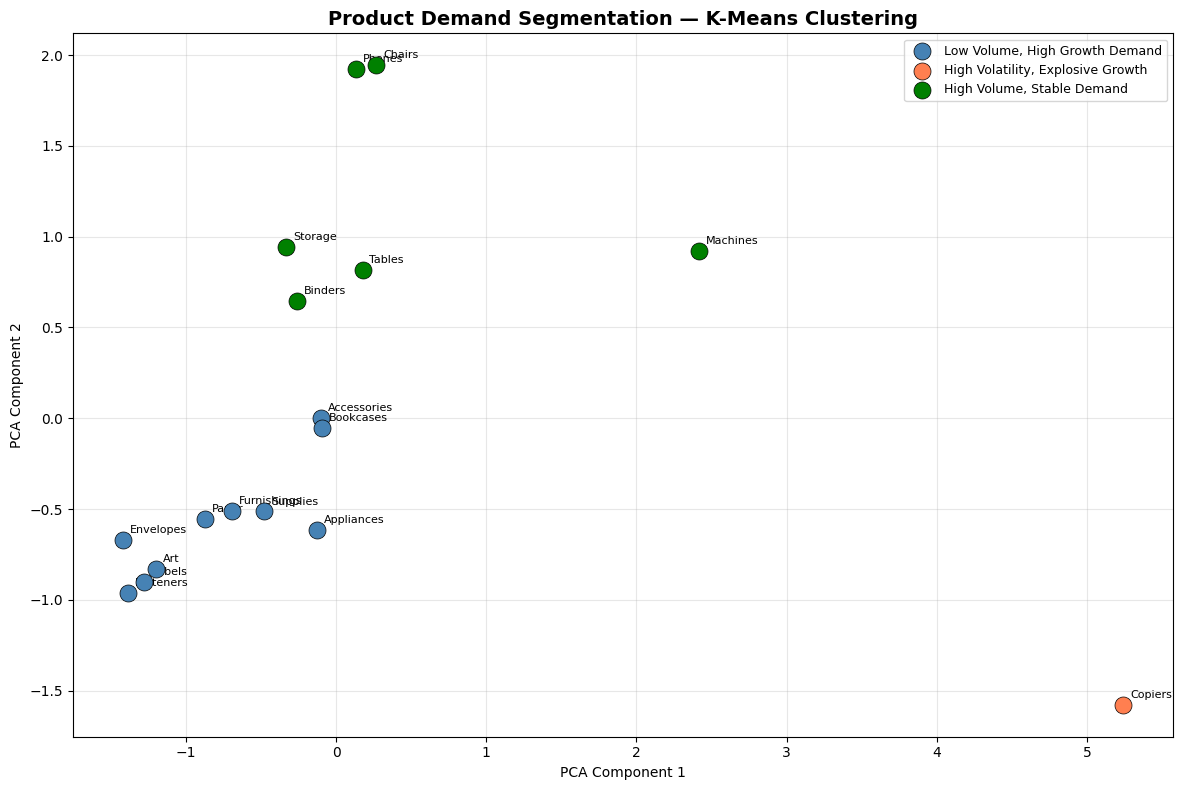

Chart 11 saved!

=== STOCKING STRATEGY PER CLUSTER ===

High Volume, Stable Demand (Phones, Chairs, Binders, Storage, Tables, Machines):
→ Maintain high safety stock — these drive most revenue!
→ Negotiate bulk purchase contracts with suppliers
→ Never let these go out of stock!

Low Volume, High Growth (Accessories, Appliances, Art, etc.):
→ Gradually increase stock as demand grows
→ Monitor monthly sales trends closely
→ Invest in marketing to accelerate growth

High Volatility, Explosive Growth (Copiers):
→ Use just-in-time ordering — demand is unpredictable
→ Keep flexible supplier agreements for quick restocking
→ One large corporate order can spike demand suddenly
→ Never overstock — storage cost outweighs benefit!



In [ ]:
# Apply KMeans with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_features['Cluster'] = kmeans.fit_predict(X_cluster)

# Analyze each cluster
print("=== CLUSTER ANALYSIS ===")
cluster_summary = cluster_features.groupby('Cluster').agg({
    'Total_Sales': 'mean',
    'Avg_Order_Value': 'mean',
    'Sales_Volatility': 'mean',
    'Growth_Rate': 'mean',
    'Sub-Category': 'count'
}).round(2)
cluster_summary.columns = ['Avg_Sales', 'Avg_Order_Value',
                            'Avg_Volatility', 'Avg_Growth%', 'Count']
print(cluster_summary)

# Correct unique labels based on actual data
cluster_labels = {
    0: "Low Volume, High Growth Demand",
    1: "High Volatility, Explosive Growth",
    2: "High Volume, Stable Demand"
}

cluster_features['Cluster_Label'] = cluster_features['Cluster'].map(cluster_labels)

print("\n=== PRODUCTS BY CLUSTER ===")
for cluster in range(3):
    label = cluster_labels[cluster]
    products = cluster_features[
        cluster_features['Cluster'] == cluster]['Sub-Category'].tolist()
    print(f"\n{label}:")
    for p in products:
        print(f"  → {p}")

# PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)
cluster_features['PCA1'] = X_pca[:, 0]
cluster_features['PCA2'] = X_pca[:, 1]

# Plot clusters
plt.figure(figsize=(12, 8))
colors = ['steelblue', 'coral', 'green']
for cluster in range(3):
    mask = cluster_features['Cluster'] == cluster
    plt.scatter(
        cluster_features[mask]['PCA1'],
        cluster_features[mask]['PCA2'],
        c=colors[cluster], s=150,
        label=cluster_labels[cluster],
        zorder=5, edgecolors='black', linewidth=0.5
    )
    for _, row in cluster_features[mask].iterrows():
        plt.annotate(row['Sub-Category'],
                    (row['PCA1'], row['PCA2']),
                    textcoords="offset points",
                    xytext=(5, 5), fontsize=8)

plt.title('Product Demand Segmentation — K-Means Clustering',
          fontsize=14, fontweight='bold')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(loc='best', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('charts/chart11_clusters.png', dpi=150)
plt.show()
print("Chart 11 saved!")

print("""
=== STOCKING STRATEGY PER CLUSTER ===

High Volume, Stable Demand (Phones, Chairs, Binders, Storage, Tables, Machines):
→ Maintain high safety stock — these drive most revenue!
→ Negotiate bulk purchase contracts with suppliers
→ Never let these go out of stock!

Low Volume, High Growth (Accessories, Appliances, Art, etc.):
→ Gradually increase stock as demand grows
→ Monitor monthly sales trends closely
→ Invest in marketing to accelerate growth

High Volatility, Explosive Growth (Copiers):
→ Use just-in-time ordering — demand is unpredictable
→ Keep flexible supplier agreements for quick restocking
→ One large corporate order can spike demand suddenly
→ Never overstock — storage cost outweighs benefit!
""")

In [ ]:
import pickle
import json

# Save monthly sales data
monthly_sales.to_csv('monthly_sales.csv', index=False)

# Save weekly sales with anomalies
weekly_sales.to_csv('weekly_sales.csv', index=False)

# Save cluster features
cluster_features.to_csv('cluster_features.csv', index=False)

# Save segment forecasts
forecast_results = {}
for name, data in results.items():
    forecast_results[name] = {
        'forecast': [float(x) for x in data['forecast']]
    }

with open('forecast_results.json', 'w') as f:
    json.dump(forecast_results, f)

# Save XGBoost model
pickle.dump(xgb_model, open('xgb_model.pkl', 'wb'))

print("All files saved!")
print("\nFiles created:")
print("  → monthly_sales.csv")
print("  → weekly_sales.csv")
print("  → cluster_features.csv")
print("  → forecast_results.json")
print("  → xgb_model.pkl")

All files saved!

Files created:
  → monthly_sales.csv
  → weekly_sales.csv
  → cluster_features.csv
  → forecast_results.json
  → xgb_model.pkl


In [ ]:
app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pickle
from xgboost import XGBRegressor

# ── PAGE CONFIG ──────────────────────────────
st.set_page_config(
    page_title="Sales Forecasting Dashboard",
    page_icon="📊",
    layout="wide"
)

# ── LOAD DATA ────────────────────────────────
@st.cache_data
def load_data():
    monthly = pd.read_csv("monthly_sales.csv", parse_dates=["Month"])
    weekly = pd.read_csv("weekly_sales.csv", parse_dates=["Week"])
    clusters = pd.read_csv("cluster_features.csv")
    with open("forecast_results.json") as f:
        forecasts = json.load(f)
    df = pd.read_csv("train.csv", encoding="latin-1")
    df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
    df["Year"] = df["Order Date"].dt.year
    df["Month_num"] = df["Order Date"].dt.month
    return monthly, weekly, clusters, forecasts, df

monthly, weekly, clusters, forecasts, df = load_data()

# ── SIDEBAR ──────────────────────────────────
st.sidebar.title("📊 Sales Intelligence")
st.sidebar.markdown("---")
page = st.sidebar.radio("Navigate to:", [
    "📊 Sales Overview",
    "🔮 Forecast Explorer",
    "⚠️ Anomaly Report",
    "🎯 Product Segments"
])

# ════════════════════════════════════════════
# PAGE 1 — SALES OVERVIEW
# ════════════════════════════════════════════
if page == "📊 Sales Overview":
    st.title("📊 Sales Overview Dashboard")
    st.markdown("---")

    # KPI Cards
    col1, col2, col3, col4 = st.columns(4)
    total_sales = df["Sales"].sum()
    avg_monthly = monthly["Sales"].mean()
    best_month = monthly.loc[monthly["Sales"].idxmax(), "Month"]
    top_category = df.groupby("Category")["Sales"].sum().idxmax()

    col1.metric("Total Sales", f"${total_sales:,.0f}")
    col2.metric("Avg Monthly Sales", f"${avg_monthly:,.0f}")
    col3.metric("Best Month", best_month.strftime("%b %Y"))
    col4.metric("Top Category", top_category)

    st.markdown("---")

    # Filters
    col1, col2 = st.columns(2)
    selected_region = col1.multiselect(
        "Filter by Region:",
        options=df["Region"].unique().tolist(),
        default=df["Region"].unique().tolist()
    )
    selected_category = col2.multiselect(
        "Filter by Category:",
        options=df["Category"].unique().tolist(),
        default=df["Category"].unique().tolist()
    )

    filtered = df[
        (df["Region"].isin(selected_region)) &
        (df["Category"].isin(selected_category))
    ]

    st.markdown("---")

    # Chart 1: Sales by Year
    col1, col2 = st.columns(2)
    with col1:
        st.subheader("Total Sales by Year")
        yearly = filtered.groupby("Year")["Sales"].sum().reset_index()
        fig, ax = plt.subplots(figsize=(8, 5))
        bars = ax.bar(yearly["Year"], yearly["Sales"],
                     color="steelblue", edgecolor="white")
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 1000,
                   f"${bar.get_height():,.0f}",
                   ha="center", va="bottom", fontsize=9)
        ax.set_xlabel("Year")
        ax.set_ylabel("Sales ($)")
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        st.pyplot(fig)

    with col2:
        st.subheader("Sales by Category")
        cat_sales = filtered.groupby("Category")["Sales"].sum().reset_index()
        fig, ax = plt.subplots(figsize=(8, 5))
        colors = ["steelblue", "coral", "green"]
        ax.bar(cat_sales["Category"], cat_sales["Sales"],
               color=colors, edgecolor="white")
        ax.set_xlabel("Category")
        ax.set_ylabel("Sales ($)")
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        st.pyplot(fig)

    # Chart 2: Monthly Trend
    st.subheader("Monthly Sales Trend")
    monthly_filtered = filtered.groupby(
        filtered["Order Date"].dt.to_period("M"))["Sales"].sum().reset_index()
    monthly_filtered["Order Date"] = monthly_filtered["Order Date"].dt.to_timestamp()
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(monthly_filtered["Order Date"], monthly_filtered["Sales"],
            color="steelblue", linewidth=2, marker="o", markersize=3)
    ax.set_xlabel("Month")
    ax.set_ylabel("Sales ($)")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    st.pyplot(fig)

    # Sales by Region
    st.subheader("Sales by Region")
    region_sales = filtered.groupby("Region")["Sales"].sum().reset_index()
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(region_sales["Region"], region_sales["Sales"],
            color="steelblue")
    ax.set_xlabel("Sales ($)")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    st.pyplot(fig)

# ════════════════════════════════════════════
# PAGE 2 — FORECAST EXPLORER
# ════════════════════════════════════════════
elif page == "🔮 Forecast Explorer":
    st.title("🔮 Forecast Explorer")
    st.markdown("---")

    segment = st.selectbox(
        "Select Segment to Forecast:",
        options=list(forecasts.keys())
    )

    months_ahead = st.slider(
        "Forecast Horizon (months):",
        min_value=1, max_value=3, value=3
    )

    st.markdown("---")

    forecast_values = forecasts[segment]["forecast"][:months_ahead]
    months = [f"Month {i+1}" for i in range(months_ahead)]

    col1, col2 = st.columns(2)

    with col1:
        st.subheader(f"Forecast — {segment}")
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.bar(months, forecast_values,
               color="steelblue", edgecolor="white")
        for i, val in enumerate(forecast_values):
            ax.text(i, val + 100, f"${val:,.0f}",
                   ha="center", va="bottom", fontsize=10)
        ax.set_ylabel("Forecasted Sales ($)")
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        st.pyplot(fig)

    with col2:
        st.subheader("Forecast Values")
        forecast_df = pd.DataFrame({
            "Period": months,
            "Forecasted Sales ($)": [f"${v:,.2f}" for v in forecast_values]
        })
        st.dataframe(forecast_df, use_container_width=True)

        st.markdown("---")
        st.subheader("Model Performance")
        st.metric("Model Used", "XGBoost")
        st.metric("MAE", "$11,551")
        st.metric("RMSE", "$14,494")
        st.metric("MAPE", "14.18%")

# ════════════════════════════════════════════
# PAGE 3 — ANOMALY REPORT
# ════════════════════════════════════════════
elif page == "⚠️ Anomaly Report":
    st.title("⚠️ Anomaly Report")
    st.markdown("---")

    method = st.radio(
        "Select Detection Method:",
        ["Isolation Forest", "Z-Score", "Both"]
    )

    st.subheader("Anomaly Detection Chart")
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(weekly["Week"], weekly["Sales"],
            color="steelblue", linewidth=1.5, label="Weekly Sales")

    if method in ["Isolation Forest", "Both"]:
        anomalies_if = weekly[weekly["Anomaly_IF"] == 1]
        ax.scatter(anomalies_if["Week"], anomalies_if["Sales"],
                  color="red", s=100, zorder=5,
                  label=f"Isolation Forest ({len(anomalies_if)} anomalies)")

    if method in ["Z-Score", "Both"]:
        anomalies_zs = weekly[weekly["Anomaly_ZS"] == 1]
        ax.scatter(anomalies_zs["Week"], anomalies_zs["Sales"],
                  color="orange", s=100, zorder=5,
                  label=f"Z-Score ({len(anomalies_zs)} anomalies)")

    ax.set_xlabel("Week")
    ax.set_ylabel("Sales ($)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    st.pyplot(fig)

    st.markdown("---")
    st.subheader("Detected Anomaly Dates")

    if method == "Isolation Forest":
        display_anomalies = weekly[weekly["Anomaly_IF"] == 1][
            ["Week", "Sales"]].reset_index(drop=True)
    elif method == "Z-Score":
        display_anomalies = weekly[weekly["Anomaly_ZS"] == 1][
            ["Week", "Sales"]].reset_index(drop=True)
    else:
        display_anomalies = weekly[
            (weekly["Anomaly_IF"] == 1) |
            (weekly["Anomaly_ZS"] == 1)][
            ["Week", "Sales"]].reset_index(drop=True)

    display_anomalies["Sales"] = display_anomalies["Sales"].apply(
        lambda x: f"${x:,.2f}")
    display_anomalies["Possible Cause"] = display_anomalies["Week"].apply(
        lambda x: "Black Friday/Christmas Season"
        if pd.to_datetime(x).month in [11, 12]
        else "Flash Sale or Promotion"
        if pd.to_datetime(x).month in [6, 7]
        else "Post-Holiday Slowdown"
        if pd.to_datetime(x).month in [1, 2]
        else "Unusual Sales Event"
    )
    st.dataframe(display_anomalies, use_container_width=True)

# ════════════════════════════════════════════
# PAGE 4 — PRODUCT SEGMENTS
# ════════════════════════════════════════════
elif page == "🎯 Product Segments":
    st.title("🎯 Product Demand Segments")
    st.markdown("---")

    st.subheader("Cluster Visualization")
    fig, ax = plt.subplots(figsize=(12, 7))
    colors = ["steelblue", "coral", "green"]
    for i, label in enumerate(clusters["Cluster_Label"].unique()):
        mask = clusters["Cluster_Label"] == label
        ax.scatter(
            clusters[mask]["PCA1"],
            clusters[mask]["PCA2"],
            c=colors[i], s=150, label=label,
            zorder=5, edgecolors="black", linewidth=0.5
        )
        for _, row in clusters[mask].iterrows():
            ax.annotate(row["Sub-Category"],
                       (row["PCA1"], row["PCA2"]),
                       textcoords="offset points",
                       xytext=(5, 5), fontsize=8)
    ax.set_xlabel("PCA Component 1")
    ax.set_ylabel("PCA Component 2")
    ax.legend(loc="best", fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    st.pyplot(fig)

    st.markdown("---")
    st.subheader("Products by Demand Cluster")

    for label in clusters["Cluster_Label"].unique():
        products = clusters[clusters["Cluster_Label"] == label][
            "Sub-Category"].tolist()
        with st.expander(f"{label} ({len(products)} products)"):
            for p in products:
                st.write(f"→ {p}")

    st.markdown("---")
    st.subheader("Recommended Stocking Strategy")
    strategies = {
        "High Volume, Stable Demand":
            "Maintain high safety stock. Negotiate bulk contracts. Never stockout!",
        "Low Volume, High Growth Demand":
            "Gradually increase stock. Monitor monthly. Invest in marketing.",
        "High Volatility, Explosive Growth":
            "Just-in-time ordering. Flexible supplier agreements. Never overstock!"
    }
    for label, strategy in strategies.items():
        st.info(f"**{label}:** {strategy}")
'''

# Save app.py
with open('app.py', 'w') as f:
    f.write(app_code)
print("app.py created!")

# Create requirements.txt
requirements = """streamlit
pandas
numpy
matplotlib
seaborn
xgboost
scikit-learn
statsmodels
prophet
plotly"""

with open('requirements.txt', 'w') as f:
    f.write(requirements)
print("requirements.txt created!")

app.py created!
requirements.txt created!
